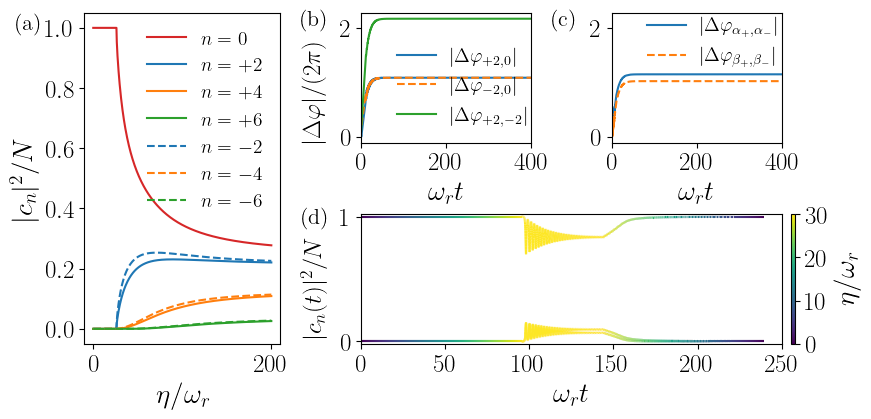

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# ==================================================
# LOAD DATA
# ==================================================
data = np.load("Figure4_data.npz")

# (a)
eta_vals = data["eta_vals"]
pop = data["pop"]
omega_r = data["omega_r"]
N = data["N"]

pop_0   = pop[:, 0]
pop_p2  = pop[:, 1]
pop_p4  = pop[:, 2]
pop_p6  = pop[:, 3]
pop_m2  = pop[:, 4]
pop_m4  = pop[:, 5]
pop_m6  = pop[:, 6]

# (b,c)
t_phase   = data["t_phase"]
delta_p0  = data["delta_p0"]
delta_m0  = data["delta_m0"]
delta_pm  = data["delta_pm"]
delta_apm = data["delta_apm"]
delta_bpm = data["delta_bpm"]

# (d)
t_ramp  = data["t_ramp"]
eta_ramp = data["eta_ramp"]
pop0_r  = data["pop0_r"]
popP_r  = data["popP_r"]
popM_r  = data["popM_r"]

# ==================================================
# HELPER FUNCTION (IMPORTANT)
# ==================================================
def colored_time_line(ax, x, y, c, cmap="viridis", lw=1.5):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap)
    lc.set_array(c)
    lc.set_linewidth(lw)

    ax.add_collection(lc)
    ax.autoscale()
    return lc

# ==================================================
# STYLE
# ==================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})

# ==================================================
# FIGURE LAYOUT
# ==================================================
fig = plt.figure(figsize=(9,4.3))

gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1.15, 1.0, 1.0],
    hspace=0.55,
    wspace=0.45
)

ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2], sharey=ax2)
ax4 = fig.add_subplot(gs[1, 1:])

# ==================================================
# (a) populations
# ==================================================
ax1.plot(eta_vals/omega_r, pop_0/N,  lw=1.5, color='C3', label=r'$n=0$')
ax1.plot(eta_vals/omega_r, pop_p2/N, lw=1.5, color='C0', label=r'$n=+2$')
ax1.plot(eta_vals/omega_r, pop_p4/N, lw=1.5, color='C1', label=r'$n=+4$')
ax1.plot(eta_vals/omega_r, pop_p6/N, lw=1.5, color='C2', label=r'$n=+6$')
ax1.plot(eta_vals/omega_r, pop_m2/N, '--', lw=1.5, color='C0', label=r'$n=-2$')
ax1.plot(eta_vals/omega_r, pop_m4/N, '--', lw=1.5, color='C1', label=r'$n=-4$')
ax1.plot(eta_vals/omega_r, pop_m6/N, '--', lw=1.5, color='C2', label=r'$n=-6$')

ax1.set_xlabel(r'$\eta / \omega_r$')
ax1.set_ylabel(r'$|c_n|^2/N$')
ax1.legend(frameon=False)
ax1.text(-0.35, 0.95, '(a)', transform=ax1.transAxes,
         fontsize=16, fontweight='bold')

# ==================================================
# (b) phase differences atoms
# ==================================================
ax2.plot(omega_r*t_phase, np.abs(delta_p0)/(2*np.pi),
         lw=1.5, label=r'$|\Delta \varphi_{+2,0}|$')

ax2.plot(omega_r*t_phase, np.abs(delta_m0)/(2*np.pi), '--',
         lw=1.5, label=r'$|\Delta \varphi_{-2,0}|$')

ax2.plot(omega_r*t_phase, np.abs(delta_pm)/(2*np.pi),
         lw=1.5, label=r'$|\Delta \varphi_{+2,-2}|$')

ax2.set_xlabel(r"$\omega_r t$")
ax2.legend(frameon=False, loc='lower right', bbox_to_anchor=(1.1, -0.01))
ax2.set_xlim([0, 400])
ax2.text(-0.35, 0.9, '(b)', transform=ax2.transAxes,
         fontsize=16, fontweight='bold')

# ==================================================
# (c) cavity phase differences
# ==================================================
ax3.plot(omega_r*t_phase, np.abs(delta_apm)/(2*np.pi),
         lw=1.5, label=r'$|\Delta \varphi_{\alpha_+,\alpha_-}|$')

ax3.plot(omega_r*t_phase, np.abs(delta_bpm)/(2*np.pi), '--',
         lw=1.5, label=r'$|\Delta \varphi_{\beta_+,\beta_-}|$')

ax3.set_xlabel(r"$\omega_r t$")
ax3.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.1, 1.1))
ax3.set_xlim([0, 400])
ax3.text(-0.35, 0.9, '(c)', transform=ax3.transAxes,
         fontsize=16, fontweight='bold')

# shared y label
fig.text(0.38, 0.7, r'$|\Delta \varphi|/(2\pi)$',
         rotation=90, va='center', ha='center', fontsize=18)

# ==================================================
# (d) ramp dynamics
# ==================================================
x = omega_r * t_ramp
c = eta_ramp / omega_r

lc0 = colored_time_line(ax4, x, pop0_r/N, c)
lcP = colored_time_line(ax4, x, popP_r/N, c)
lcM = colored_time_line(ax4, x, popM_r/N, c)

ax4.set_xlim(0,250)
ax4.set_ylim(-0.02,1.02)
ax4.set_xlabel(r"$\omega_r t$")

fig.text(0.38, 0.24, r"$|c_n(t)|^2/N$",
         rotation=90, va='center', ha='center', fontsize=18)

ax4.text(-0.14, 0.93, '(d)', transform=ax4.transAxes,
         fontsize=16, fontweight='bold')

# ==================================================
# COLORBAR
# ==================================================
pos = ax4.get_position()

cax = fig.add_axes([
    pos.x1 + 0.01,
    pos.y0,
    0.005,
    pos.height
])

cbar = fig.colorbar(lc0, cax=cax)
ticks = np.linspace(c.min(), c.max(), 4)
cbar.set_ticks(ticks)
cbar.set_label(r'$\eta / \omega_r$')

plt.show()